STEP 1: PROBLEM DEFINITION
----------------------------------------
PROBLEM: Predict whether a loan applicant will DEFAULT (1) or NOT DEFAULT (0)

GOAL: Binary classification

SUCCESS CRITERIA:
- Accuracy: >80%
- Precision: >75%
- Recall: >70%
- F1-Score: >72%

# STEP 2: DATA COLLECTION
 - Source: Kaggle dataset 'loan_default_prediction.csv'
 - URL: https://www.kaggle.com/datasets/sahideseker/loan-default-prediction-dataset
 - This dataset contains loan application information with a binary target indicating default (1) or not (0).
 -  It includes features relevant to credit risk assessment (income, loan amount, employment status, etc.).


In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('loan_default_prediction.csv')

# Quick check that data represents the problem domain
print("Step 2: Data Collection")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Default rate: {df['default'].mean()*100:.2f}%")
print(f"Features: {list(df.columns)}")  # Optional: shows all columns

Step 2: Data Collection
Dataset shape: 1000 rows, 5 columns
Default rate: 48.70%
Features: ['loan_id', 'income', 'loan_amount', 'employment_status', 'default']


# STEP 3: DATA EXPLORATION AND PREPARATION
 # 3.1 Exploratory Data Analysis (EDA): 
 - Understand distributions of target and key features
- Visualize relationships between features and default status
- Identify trends (e.g., income/loan amount differences by default)

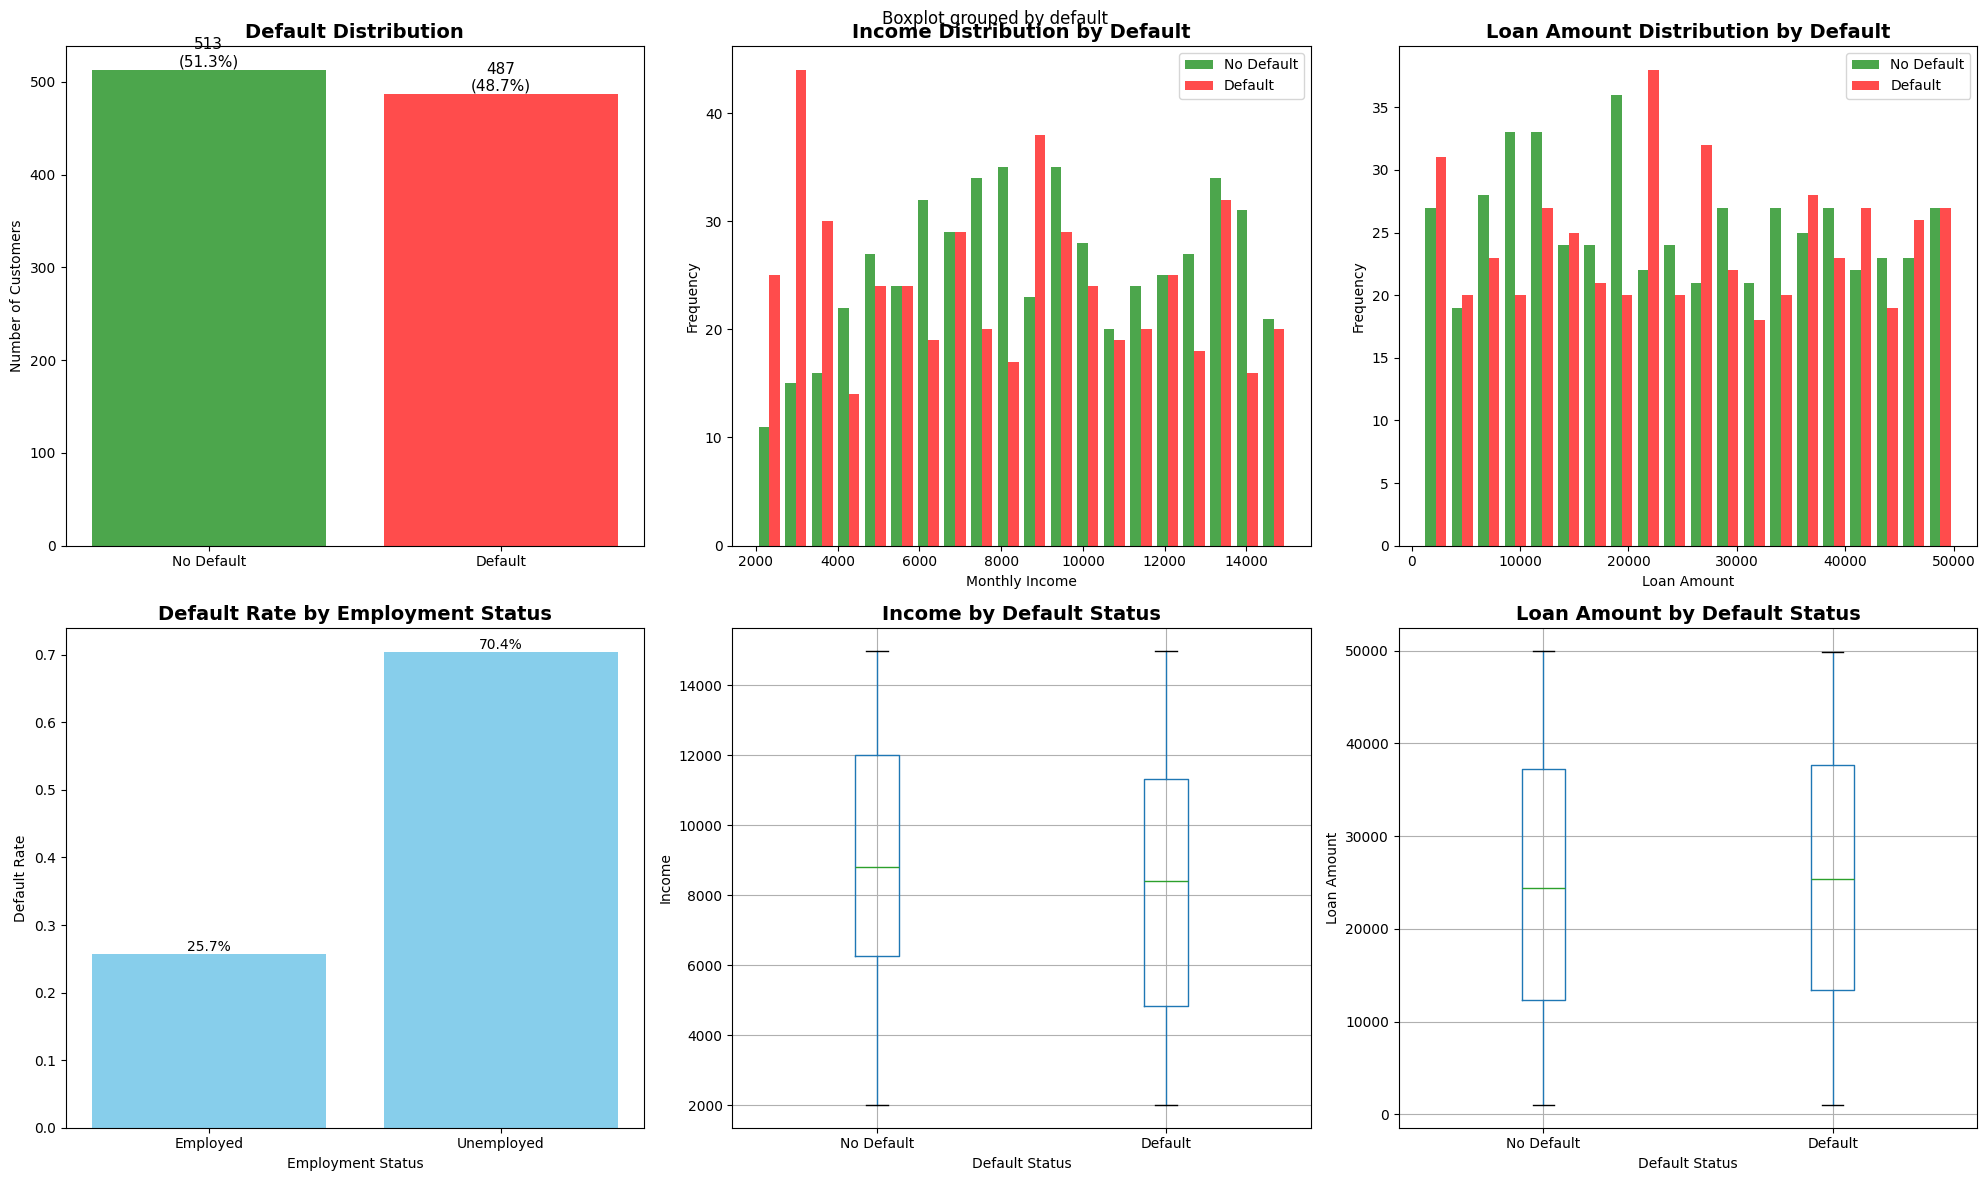

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Create a figure with multiple subplots to explore data
fig = plt.figure(figsize=(20, 12))
fig.suptitle("EDA: Loan Default Prediction", fontsize=16, y=0.98)

# 1. Target variable distribution
ax1 = plt.subplot(2, 3, 1)
default_counts = df['default'].value_counts()
colors = ['green', 'red']
bars = ax1.bar(['No Default', 'Default'], default_counts.values, color=colors, alpha=0.7)
ax1.set_title('Default Distribution', fontsize=14, fontweight='bold')
ax1.set_ylabel('Number of Customers')
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}\n({height/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=11)

# 2. Income distribution by default status
ax2 = plt.subplot(2, 3, 2)
ax2.hist([df[df['default']==0]['income'], df[df['default']==1]['income']],
         bins=20, label=['No Default', 'Default'], alpha=0.7, color=['green', 'red'])
ax2.set_title('Income Distribution by Default', fontsize=14, fontweight='bold')
ax2.set_xlabel('Monthly Income')
ax2.set_ylabel('Frequency')
ax2.legend()

# 3. Loan amount distribution by default status
ax3 = plt.subplot(2, 3, 3)
ax3.hist([df[df['default']==0]['loan_amount'], df[df['default']==1]['loan_amount']],
         bins=20, label=['No Default', 'Default'], alpha=0.7, color=['green', 'red'])
ax3.set_title('Loan Amount Distribution by Default', fontsize=14, fontweight='bold')
ax3.set_xlabel('Loan Amount')
ax3.set_ylabel('Frequency')
ax3.legend()

# 4. Default rate by employment status
ax4 = plt.subplot(2, 3, 4)
emp_default = df.groupby('employment_status')['default'].mean().sort_values()
bars = ax4.bar(emp_default.index, emp_default.values, color='skyblue')
ax4.set_title('Default Rate by Employment Status', fontsize=14, fontweight='bold')
ax4.set_ylabel('Default Rate')
ax4.set_xlabel('Employment Status')
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{height*100:.1f}%', ha='center', va='bottom', fontsize=10)

# 5. Box plot: income vs default
ax5 = plt.subplot(2, 3, 5)
df.boxplot(column='income', by='default', ax=ax5)
ax5.set_title('Income by Default Status', fontsize=14, fontweight='bold')
ax5.set_xlabel('Default Status')
ax5.set_ylabel('Income')
ax5.set_xticklabels(['No Default', 'Default'])

# 6. Box plot: loan amount vs default
ax6 = plt.subplot(2, 3, 6)
df.boxplot(column='loan_amount', by='default', ax=ax6)
ax6.set_title('Loan Amount by Default Status', fontsize=14, fontweight='bold')
ax6.set_xlabel('Default Status')
ax6.set_ylabel('Loan Amount')
ax6.set_xticklabels(['No Default', 'Default'])

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()


# 3.2: DATA CLEANING
- Handle missing values, remove duplicates, and cap outliers
- to prepare data for modeling.

✅ No missing values found.
✅ No duplicates found.


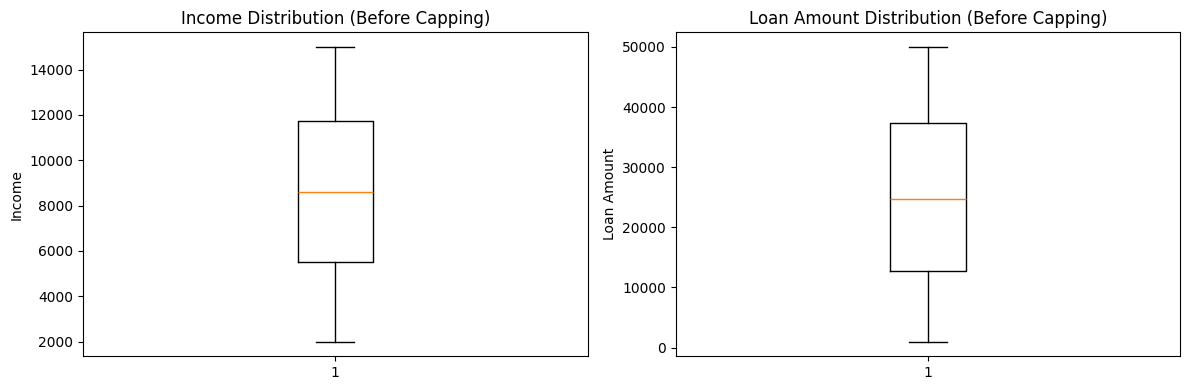


🔧 Capping outliers using IQR method...
  income: 0 outliers detected
  loan_amount: 0 outliers detected


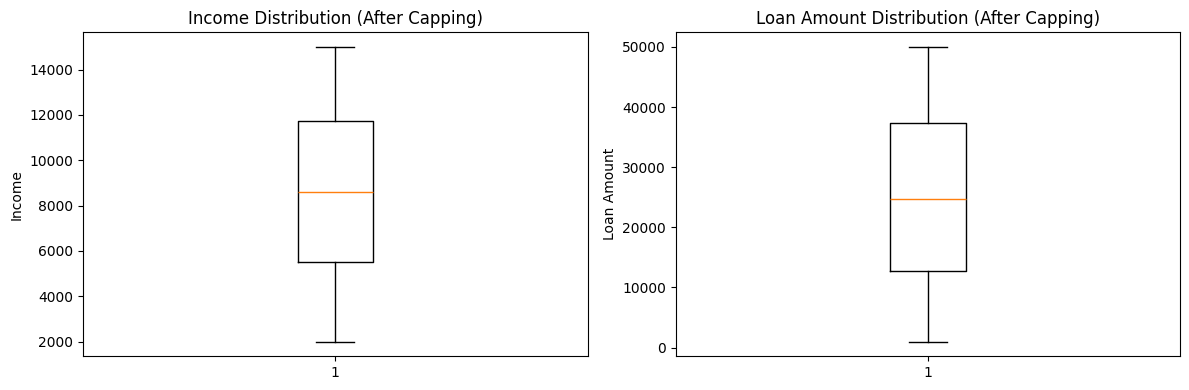


✅ Cleaning complete. Final shape: (1000, 5)


In [3]:
import matplotlib.pyplot as plt

df_clean = df.copy()

# 1. Missing values
missing = df_clean.isnull().sum()
if missing.sum() > 0:
    df_clean = df_clean.dropna()
    print(f"Dropped rows with missing values. New shape: {df_clean.shape}")
else:
    print("✅ No missing values found.")

# 2. Duplicates
duplicates = df_clean.duplicated().sum()
if duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print(f"Removed {duplicates} duplicate rows.")
else:
    print("✅ No duplicates found.")

# 3. Visualize outliers BEFORE capping (optional)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df_clean['income'])
axes[0].set_title('Income Distribution (Before Capping)')
axes[0].set_ylabel('Income')
axes[1].boxplot(df_clean['loan_amount'])
axes[1].set_title('Loan Amount Distribution (Before Capping)')
axes[1].set_ylabel('Loan Amount')
plt.tight_layout()
plt.show()

# 4. Cap outliers using IQR method
numerical_cols = ['income', 'loan_amount']
print("\n🔧 Capping outliers using IQR method...")

for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # Count outliers before capping
    outliers_before = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)].shape[0]
    print(f"  {col}: {outliers_before} outliers detected")
    
    # Cap outliers
    df_clean[col] = df_clean[col].clip(lower, upper)

# 5. Visualize outliers AFTER capping (optional)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df_clean['income'])
axes[0].set_title('Income Distribution (After Capping)')
axes[0].set_ylabel('Income')
axes[1].boxplot(df_clean['loan_amount'])
axes[1].set_title('Loan Amount Distribution (After Capping)')
axes[1].set_ylabel('Loan Amount')
plt.tight_layout()
plt.show()

print(f"\n✅ Cleaning complete. Final shape: {df_clean.shape}")

#  3.3: FEATURE ENGINEERING
- Create new features, encode categorical variables, and scale numerical features.

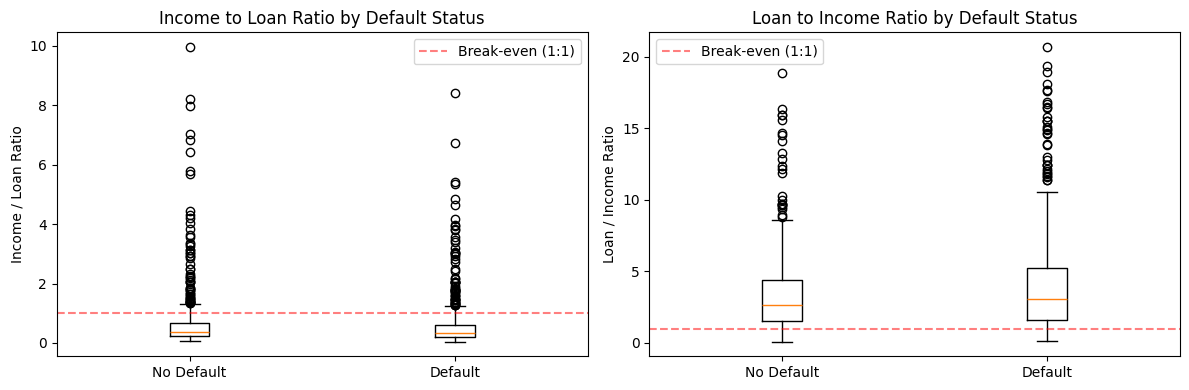

Feature engineering complete. New shape: (1000, 7)


In [4]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

df_fe = df_clean.copy()

# 1. Create new features
df_fe['income_to_loan'] = df_fe['income'] / df_fe['loan_amount']
df_fe['loan_to_income'] = df_fe['loan_amount'] / df_fe['income']

# 2. Visualize new features (optional)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Income to Loan Ratio by default status
axes[0].boxplot([df_fe[df_fe['default']==0]['income_to_loan'],
                 df_fe[df_fe['default']==1]['income_to_loan']],
                tick_labels=['No Default', 'Default'])
axes[0].set_title('Income to Loan Ratio by Default Status')
axes[0].set_ylabel('Income / Loan Ratio')
axes[0].axhline(y=1, color='r', linestyle='--', alpha=0.5, label='Break-even (1:1)')
axes[0].legend()

# Loan to Income Ratio by default status
axes[1].boxplot([df_fe[df_fe['default']==0]['loan_to_income'],
                 df_fe[df_fe['default']==1]['loan_to_income']],
                tick_labels=['No Default', 'Default'])
axes[1].set_title('Loan to Income Ratio by Default Status')
axes[1].set_ylabel('Loan / Income Ratio')
axes[1].axhline(y=1, color='r', linestyle='--', alpha=0.5, label='Break-even (1:1)')
axes[1].legend()

plt.tight_layout()
plt.show()

# 3. One-hot encode employment_status
df_fe = pd.get_dummies(df_fe, columns=['employment_status'], prefix='emp', drop_first=True)

# 4. Scale numerical features
numerical_cols = ['income', 'loan_amount', 'income_to_loan', 'loan_to_income']
scaler = StandardScaler()
df_fe[numerical_cols] = scaler.fit_transform(df_fe[numerical_cols])

print(f"Feature engineering complete. New shape: {df_fe.shape}")

In [5]:
import joblib

# Save the fitted scaler
joblib.dump(scaler, 'scaler.pkl')

# Save the feature column names (the order matters for prediction)
feature_columns = df_fe.drop(['default', 'loan_id'], axis=1).columns.tolist()
joblib.dump(feature_columns, 'feature_columns.pkl')

print("✅ Artifacts saved for deployment:")
print("   - scaler.pkl")
print("   - feature_columns.pkl")

✅ Artifacts saved for deployment:
   - scaler.pkl
   - feature_columns.pkl


#  3.4: DATA SPLITTING
- Split the fully engineered data into training, validation, and test sets

In [6]:
from sklearn.model_selection import train_test_split

X = df_fe.drop(['default', 'loan_id'], axis=1)
y = df_fe['default']

# Split into train (60%), val (20%), test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"Training set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"Test set: {len(X_test)} samples")

Training set: 600 samples
Validation set: 200 samples
Test set: 200 samples


# STEP 4 & 5: ALGORITHM SELECTION, MODEL DEVELOPMENT, AND TRAINING

## 4. Algorithm Selection

Problem Type: Binary Classification (Default: 1, No Default: 0)

Selected Algorithm: LOGISTIC REGRESSION

Why Logistic Regression?
- Supervised learning algorithm specifically designed for binary classification
- Outputs probabilities between 0 and 1 (interpretable as risk scores)
- Low complexity → fast training and prediction
- High interpretability → coefficients show feature importance
- Low computational cost → suitable for production deployment
- Performs well with linearly separable data

Alternative algorithms considered:
- Random Forest: Higher complexity, less interpretable, higher computational cost
- Neural Networks: Overkill for this problem, requires more data
- SVM: Less interpretable, higher complexity

Therefore, Logistic Regression is the most appropriate choice.

 - Selected Algorithm: LOGISTIC REGRESSION
 - Type: Supervised Learning (Classification)
 - Complexity: Low
 - Interpretability: High
 - Computational Cost: Lo

## 5. Model Development and Training

1. Design and create the model: Logistic Regression with default hyperparameters
2. Train the model on training dataset
3. Use suitable hyperparameters (C=1.0, penalty='l2', solver='lbfgs')

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

print("STEP 5: MODEL DEVELOPMENT AND TRAINING")
print("="*60)

# 1. Create baseline model (without deprecated penalty parameter)
print("\n📊 Creating Baseline Logistic Regression Model...")
print("-" * 40)

baseline_model = LogisticRegression(
    C=1.0,              # Default regularization strength
    solver='lbfgs',     # Optimization algorithm
    max_iter=1000,      # Maximum iterations for convergence
    random_state=42     # For reproducibility
)

print("✅ Baseline model created: LogisticRegression(C=1.0, solver='lbfgs')")

# 2. Train baseline model
print("\n📊 Training baseline model...")
print("-" * 40)
baseline_model.fit(X_train, y_train)
print("✅ Baseline model training complete!")

# 3. Evaluate baseline model
print("\n📊 Baseline Model Validation Performance:")
print("-" * 40)

y_pred = baseline_model.predict(X_val)
y_proba = baseline_model.predict_proba(X_val)[:, 1]

accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
auc = roc_auc_score(y_val, y_proba)

print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
print(f"ROC-AUC:   {auc:.4f}")

# Check success criteria
print("\n" + "="*60)
print("SUCCESS CRITERIA CHECK (Baseline Model)")
print("="*60)
print(f"Accuracy >80%:  {'✅ PASSED' if accuracy > 0.80 else '❌ FAILED'} (Target: 80%, Achieved: {accuracy*100:.1f}%)")
print(f"Precision >75%: {'✅ PASSED' if precision > 0.75 else '❌ FAILED'} (Target: 75%, Achieved: {precision*100:.1f}%)")
print(f"Recall >70%:    {'✅ PASSED' if recall > 0.70 else '❌ FAILED'} (Target: 70%, Achieved: {recall*100:.1f}%)")
print(f"F1-Score >72%:  {'✅ PASSED' if f1 > 0.72 else '❌ FAILED'} (Target: 72%, Achieved: {f1*100:.1f}%)")

# 4. Hyperparameter Tuning to improve performance
print("\n" + "="*60)
print("HYPERPARAMETER TUNING")
print("="*60)

# Parameter grid for tuning
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],     # Regularization strength
    'solver': ['lbfgs', 'liblinear']           # Optimization algorithms
}

print("\n🔧 Performing Grid Search with 5-fold Cross Validation...")
print(f"Parameter grid: {len(param_grid['C'])} × {len(param_grid['solver'])} = {len(param_grid['C']) * len(param_grid['solver'])} combinations")

# Grid Search
grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
best_params = grid_search.best_params_

print(f"\n✅ Best Parameters: {best_params}")
print(f"✅ Best CV ROC-AUC Score: {grid_search.best_score_:.4f}")

# 5. Evaluate tuned model
print("\n📊 Tuned Model Validation Performance:")
print("-" * 40)

y_pred_tuned = best_model.predict(X_val)
y_proba_tuned = best_model.predict_proba(X_val)[:, 1]

accuracy_tuned = accuracy_score(y_val, y_pred_tuned)
precision_tuned = precision_score(y_val, y_pred_tuned)
recall_tuned = recall_score(y_val, y_pred_tuned)
f1_tuned = f1_score(y_val, y_pred_tuned)
auc_tuned = roc_auc_score(y_val, y_proba_tuned)

print(f"Accuracy:  {accuracy_tuned:.4f} ({accuracy_tuned*100:.2f}%)")
print(f"Precision: {precision_tuned:.4f} ({precision_tuned*100:.2f}%)")
print(f"Recall:    {recall_tuned:.4f} ({recall_tuned*100:.2f}%)")
print(f"F1-Score:  {f1_tuned:.4f} ({f1_tuned*100:.2f}%)")
print(f"ROC-AUC:   {auc_tuned:.4f}")

# 6. Compare performance
print("\n" + "="*60)
print("PERFORMANCE COMPARISON")
print("="*60)
print(f"{'Metric':<12} {'Baseline':<12} {'Tuned':<12} {'Improvement':<12}")
print("-" * 55)
print(f"{'Accuracy':<12} {accuracy:.4f}      {accuracy_tuned:.4f}      {(accuracy_tuned - accuracy)*100:+.2f}%")
print(f"{'Precision':<12} {precision:.4f}      {precision_tuned:.4f}      {(precision_tuned - precision)*100:+.2f}%")
print(f"{'Recall':<12} {recall:.4f}      {recall_tuned:.4f}      {(recall_tuned - recall)*100:+.2f}%")
print(f"{'F1-Score':<12} {f1:.4f}      {f1_tuned:.4f}      {(f1_tuned - f1)*100:+.2f}%")
print(f"{'ROC-AUC':<12} {auc:.4f}      {auc_tuned:.4f}      {(auc_tuned - auc)*100:+.2f}%")

# 7. Check success criteria with tuned model
print("\n" + "="*60)
print("SUCCESS CRITERIA CHECK (Tuned Model)")
print("="*60)
print(f"Accuracy >80%:  {'✅ PASSED' if accuracy_tuned > 0.80 else '❌ FAILED'} (Target: 80%, Achieved: {accuracy_tuned*100:.1f}%)")
print(f"Precision >75%: {'✅ PASSED' if precision_tuned > 0.75 else '❌ FAILED'} (Target: 75%, Achieved: {precision_tuned*100:.1f}%)")
print(f"Recall >70%:    {'✅ PASSED' if recall_tuned > 0.70 else '❌ FAILED'} (Target: 70%, Achieved: {recall_tuned*100:.1f}%)")
print(f"F1-Score >72%:  {'✅ PASSED' if f1_tuned > 0.72 else '❌ FAILED'} (Target: 72%, Achieved: {f1_tuned*100:.1f}%)")

# 8. Select final model
if accuracy_tuned > accuracy:
    final_model = best_model
    print("\n✅ Tuned model selected as final model (better performance)")
else:
    final_model = baseline_model
    print("\n✅ Baseline model selected as final model")


STEP 5: MODEL DEVELOPMENT AND TRAINING

📊 Creating Baseline Logistic Regression Model...
----------------------------------------
✅ Baseline model created: LogisticRegression(C=1.0, solver='lbfgs')

📊 Training baseline model...
----------------------------------------
✅ Baseline model training complete!

📊 Baseline Model Validation Performance:
----------------------------------------
Accuracy:  0.6700 (67.00%)
Precision: 0.6476 (64.76%)
Recall:    0.7010 (70.10%)
F1-Score:  0.6733 (67.33%)
ROC-AUC:   0.6980

SUCCESS CRITERIA CHECK (Baseline Model)
Accuracy >80%:  ❌ FAILED (Target: 80%, Achieved: 67.0%)
Precision >75%: ❌ FAILED (Target: 75%, Achieved: 64.8%)
Recall >70%:    ✅ PASSED (Target: 70%, Achieved: 70.1%)
F1-Score >72%:  ❌ FAILED (Target: 72%, Achieved: 67.3%)

HYPERPARAMETER TUNING

🔧 Performing Grid Search with 5-fold Cross Validation...
Parameter grid: 6 × 2 = 12 combinations
Fitting 5 folds for each of 12 candidates, totalling 60 fits

✅ Best Parameters: {'C': 0.1, 'solver'

# STEP 6: MODEL EVALUATION AND HYPERPARAMETER TUNING

STEP 6: MODEL EVALUATION AND HYPERPARAMETER TUNING

1. BASELINE MODEL EVALUATION
----------------------------------------
Training Set:
  Accuracy: 0.7317 | Precision: 0.7063 | Recall: 0.7713 | F1: 0.7374

Validation Set:
  Accuracy: 0.6700 | Precision: 0.6476 | Recall: 0.7010 | F1: 0.6733 | AUC: 0.6980

2. UNDERFITTING/OVERFITTING ANALYSIS
----------------------------------------
✅ No severe issues (Train-Val gap: 0.0617)

3. HYPERPARAMETER TUNING (Grid Search)
----------------------------------------
Best Parameters: C=0.1, solver=lbfgs
Best Cross-Validation AUC: 0.7427

4. OPTIMIZED MODEL EVALUATION
----------------------------------------
Accuracy:  0.6700 (67.00%)
Precision: 0.6476 (64.76%)
Recall:    0.7010 (70.10%)
F1-Score:  0.6733 (67.33%)
ROC-AUC:   0.6901

5. PERFORMANCE COMPARISON
----------------------------------------
Metric       Baseline     Optimized    Change      
--------------------------------------------------
Accuracy     0.6700      0.6700      +0.00%
Precisio

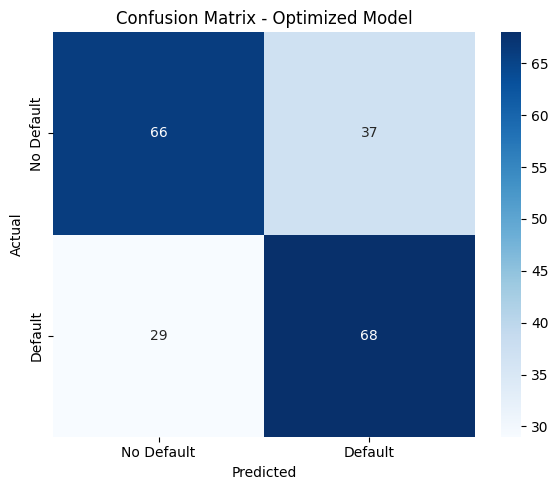


7. ROC CURVE
----------------------------------------


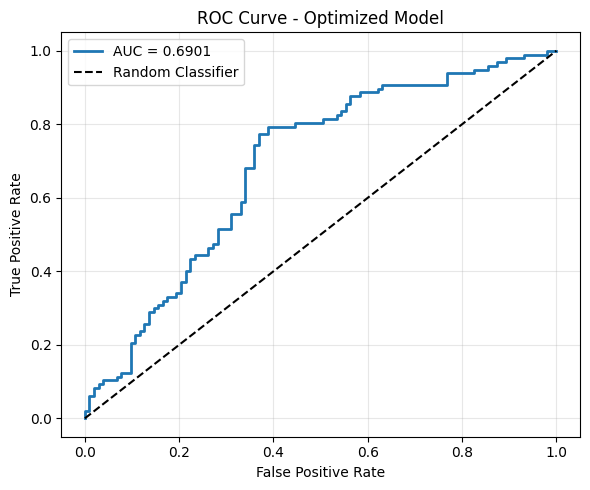

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("STEP 6: MODEL EVALUATION AND HYPERPARAMETER TUNING")
print("="*60)

# 1. Baseline Model Evaluation on Validation Set
print("\n1. BASELINE MODEL EVALUATION")
print("-" * 40)

baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline.fit(X_train, y_train)

y_pred_train = baseline.predict(X_train)
y_pred_val = baseline.predict(X_val)
y_proba_val = baseline.predict_proba(X_val)[:, 1]

# Classification metrics
accuracy_train = accuracy_score(y_train, y_pred_train)
precision_train = precision_score(y_train, y_pred_train)
recall_train = recall_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train)

accuracy_val = accuracy_score(y_val, y_pred_val)
precision_val = precision_score(y_val, y_pred_val)
recall_val = recall_score(y_val, y_pred_val)
f1_val = f1_score(y_val, y_pred_val)
auc_val = roc_auc_score(y_val, y_proba_val)

print("Training Set:")
print(f"  Accuracy: {accuracy_train:.4f} | Precision: {precision_train:.4f} | Recall: {recall_train:.4f} | F1: {f1_train:.4f}")
print("\nValidation Set:")
print(f"  Accuracy: {accuracy_val:.4f} | Precision: {precision_val:.4f} | Recall: {recall_val:.4f} | F1: {f1_val:.4f} | AUC: {auc_val:.4f}")

# 2. Identify Underfitting/Overfitting
print("\n2. UNDERFITTING/OVERFITTING ANALYSIS")
print("-" * 40)

train_val_gap = accuracy_train - accuracy_val
if train_val_gap > 0.1:
    print(f"⚠️ Overfitting detected (Train-Val gap: {train_val_gap:.4f})")
elif accuracy_train < 0.6 and accuracy_val < 0.6:
    print("⚠️ Possible underfitting (low accuracy scores)")
else:
    print(f"✅ No severe issues (Train-Val gap: {train_val_gap:.4f})")

# 3. Hyperparameter Tuning using Grid Search
print("\n3. HYPERPARAMETER TUNING (Grid Search)")
print("-" * 40)

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear']
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
best_params = grid_search.best_params_

print(f"Best Parameters: C={best_params['C']}, solver={best_params['solver']}")
print(f"Best Cross-Validation AUC: {grid_search.best_score_:.4f}")

# 4. Optimized Model Evaluation on Validation Set
print("\n4. OPTIMIZED MODEL EVALUATION")
print("-" * 40)

y_pred_opt = best_model.predict(X_val)
y_proba_opt = best_model.predict_proba(X_val)[:, 1]

accuracy_opt = accuracy_score(y_val, y_pred_opt)
precision_opt = precision_score(y_val, y_pred_opt)
recall_opt = recall_score(y_val, y_pred_opt)
f1_opt = f1_score(y_val, y_pred_opt)
auc_opt = roc_auc_score(y_val, y_proba_opt)

print(f"Accuracy:  {accuracy_opt:.4f} ({accuracy_opt*100:.2f}%)")
print(f"Precision: {precision_opt:.4f} ({precision_opt*100:.2f}%)")
print(f"Recall:    {recall_opt:.4f} ({recall_opt*100:.2f}%)")
print(f"F1-Score:  {f1_opt:.4f} ({f1_opt*100:.2f}%)")
print(f"ROC-AUC:   {auc_opt:.4f}")

# 5. Performance Comparison
print("\n5. PERFORMANCE COMPARISON")
print("-" * 40)
print(f"{'Metric':<12} {'Baseline':<12} {'Optimized':<12} {'Change':<12}")
print("-" * 50)
print(f"{'Accuracy':<12} {accuracy_val:.4f}      {accuracy_opt:.4f}      {(accuracy_opt - accuracy_val)*100:+.2f}%")
print(f"{'Precision':<12} {precision_val:.4f}      {precision_opt:.4f}      {(precision_opt - precision_val)*100:+.2f}%")
print(f"{'Recall':<12} {recall_val:.4f}      {recall_opt:.4f}      {(recall_opt - recall_val)*100:+.2f}%")
print(f"{'F1-Score':<12} {f1_val:.4f}      {f1_opt:.4f}      {(f1_opt - f1_val)*100:+.2f}%")
print(f"{'AUC':<12} {auc_val:.4f}      {auc_opt:.4f}      {(auc_opt - auc_val)*100:+.2f}%")

# 6. Confusion Matrix (Optimized Model)
print("\n6. CONFUSION MATRIX (Optimized Model)")
print("-" * 40)

cm = confusion_matrix(y_val, y_pred_opt)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix - Optimized Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# 7. ROC Curve
print("\n7. ROC CURVE")
print("-" * 40)

from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_val, y_proba_opt)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc_opt:.4f}', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Optimized Model')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [9]:
joblib.dump(best_model, 'loan_default_model.pkl')

['loan_default_model.pkl']

# STEP 8: MODEL TESTING AND DEPLOYMENT

STEP 8: MODEL TESTING AND DEPLOYMENT

📊 FINAL MODEL EVALUATION ON TEST SET
----------------------------------------
Accuracy:  0.7850 (78.50%)
Precision: 0.7455 (74.55%)
Recall:    0.8454 (84.54%)
F1-Score:  0.7923 (79.23%)
ROC-AUC:   0.7941

----------------------------------------
SUCCESS CRITERIA CHECK (from Step 1):
Accuracy >80%:  ❌ FAILED (Target: 80%, Achieved: 78.5%)
Precision >75%: ❌ FAILED (Target: 75%, Achieved: 74.5%)
Recall >70%:    ✅ PASSED (Target: 70%, Achieved: 84.5%)
F1-Score >72%:  ✅ PASSED (Target: 72%, Achieved: 79.2%)

📊 CONFUSION MATRIX
----------------------------------------


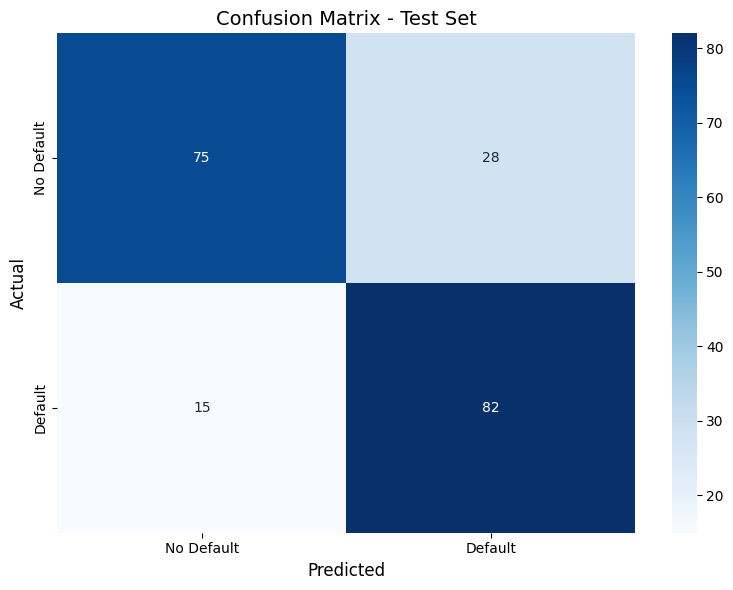


📊 CLASSIFICATION REPORT
----------------------------------------
              precision    recall  f1-score   support

  No Default       0.83      0.73      0.78       103
     Default       0.75      0.85      0.79        97

    accuracy                           0.79       200
   macro avg       0.79      0.79      0.78       200
weighted avg       0.79      0.79      0.78       200


💾 SAVING MODEL AND ARTIFACTS
----------------------------------------


['feature_columns.pkl']

In [10]:
import joblib
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("STEP 8: MODEL TESTING AND DEPLOYMENT")
print("="*60)

# 1. Evaluate final model on test set
print("\n📊 FINAL MODEL EVALUATION ON TEST SET")
print("-" * 40)

# Predictions
y_pred_test = best_model.predict(X_test)
y_proba_test = best_model.predict_proba(X_test)[:, 1]

# Classification metrics
accuracy = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)
auc = roc_auc_score(y_test, y_proba_test)

print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
print(f"ROC-AUC:   {auc:.4f}")

# Check against success criteria (from Step 1)
print("\n" + "-" * 40)
print("SUCCESS CRITERIA CHECK (from Step 1):")
print(f"Accuracy >80%:  {'✅ PASSED' if accuracy > 0.80 else '❌ FAILED'} (Target: 80%, Achieved: {accuracy*100:.1f}%)")
print(f"Precision >75%: {'✅ PASSED' if precision > 0.75 else '❌ FAILED'} (Target: 75%, Achieved: {precision*100:.1f}%)")
print(f"Recall >70%:    {'✅ PASSED' if recall > 0.70 else '❌ FAILED'} (Target: 70%, Achieved: {recall*100:.1f}%)")
print(f"F1-Score >72%:  {'✅ PASSED' if f1 > 0.72 else '❌ FAILED'} (Target: 72%, Achieved: {f1*100:.1f}%)")

# 2. Confusion Matrix
print("\n📊 CONFUSION MATRIX")
print("-" * 40)

cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix - Test Set', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

# 3. Classification Report
print("\n📊 CLASSIFICATION REPORT")
print("-" * 40)
print(classification_report(y_test, y_pred_test, target_names=['No Default', 'Default']))

# 4. Save all objects needed for deployment
print("\n💾 SAVING MODEL AND ARTIFACTS")
print("-" * 40)

joblib.dump(best_model, 'loan_default_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(feature_columns, 'feature_columns.pkl')


